# Big Data Processing Algorithm
### Project: Word Count Analysis

In [7]:
!pip install pandas matplotlib nltk wordcloud

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Program Files\Python311\python.exe -m pip install --upgrade pip


In [16]:
import os
import re
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
from itertools import islice
import nltk
from nltk.corpus import stopwords
from nltk.util import ngrams
from wordcloud import WordCloud

# Download the stopwords dictionary
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ACER\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


In [ ]:
folder_path = r"F:\GithubProjects\Word-Count-Project\folder"  # Folder containing text files
all_words = []

In [ ]:
def clean_and_map_text(text):
    text = text.lower()
    text = re.sub(r"[^\w\s]", "", text)  # Remove punctuation
    # Split, remove stopwords, and ignore pure numbers
    return [word for word in text.split() if word not in stop_words and not word.isdigit()]

if os.path.exists(folder_path):
    for filename in os.listdir(folder_path):
        if filename.endswith(".txt"):
            with open(os.path.join(folder_path, filename), "r", encoding="utf-8") as f:
                mapped_words = clean_and_map_text(f.read())
                all_words.extend(mapped_words)
    print(f"Total valid words processed (excluding stopwords): {len(all_words)}")
else:
    print(f"Error: Could not find the folder '{folder_path}'. Please create it and add text files.")

Success: Found folder. It contains 3 items.
Looking at: 'file1.txt'
 ---> Processing 'file1.txt'...
Looking at: 'file2.txt'
 ---> Processing 'file2.txt'...
Looking at: 'file3.txt'
 ---> Processing 'file3.txt'...

Total valid words processed: 0


In [18]:
# Step 2: Word Count (MapReduce Style)

word_counts = Counter(all_words)
print("\nTop 10 most frequent words:")
for word, count in word_counts.most_common(10):
    print(f"{word}: {count}")


Top 10 most frequent words:


In [13]:
# Step 3: N-Gram Analysis (Bigrams)

bigrams = zip(all_words, all_words[1:])
bigram_counts = Counter(bigrams)
print("\nTop 10 Bigrams:")
for bg, count in bigram_counts.most_common(10):
    print(f"{bg}: {count}")


Top 10 Bigrams:


In [14]:
# Step 4: Convert Word Count to DataFrame for Analysis

df_word_count = pd.DataFrame(word_counts.items(), columns=["Word", "Count"])
df_word_count = df_word_count.sort_values(by="Count", ascending=False)
print("\nWord count DataFrame head:\n", df_word_count.head())


Word count DataFrame head:
 Empty DataFrame
Columns: [Word, Count]
Index: []



Total unique words: 0


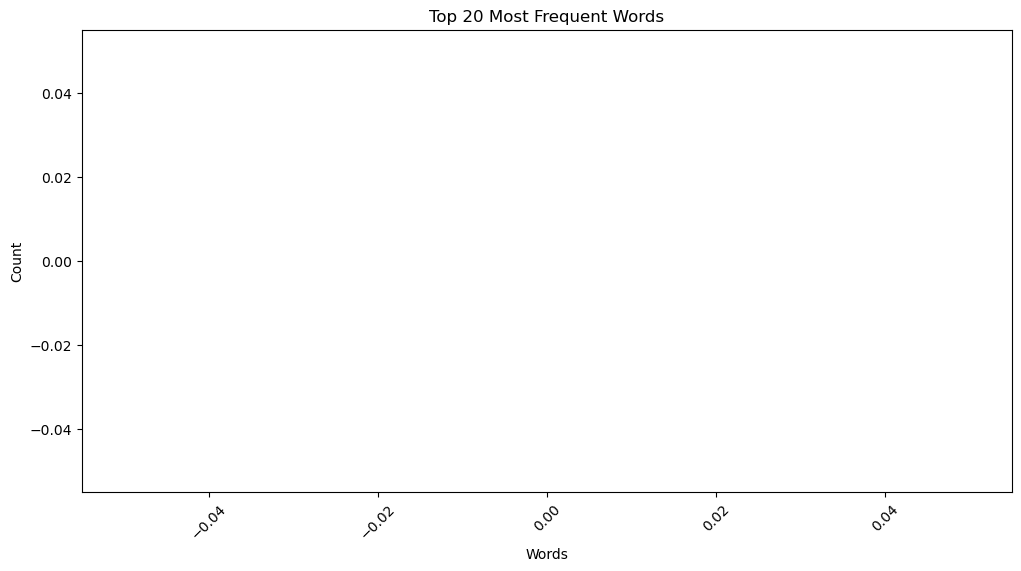

In [15]:
#  Step 5: Simple Exploratory Data Analysis

# Total unique words
print("\nTotal unique words:", df_word_count.shape[0])

# Top 20 words visualization
top20 = df_word_count.head(20)
plt.figure(figsize=(12,6))
plt.bar(top20['Word'], top20['Count'], color='skyblue')
plt.xticks(rotation=45)
plt.title("Top 20 Most Frequent Words")
plt.xlabel("Words")
plt.ylabel("Count")
plt.show()

In [ ]:
# Function to generate ngrams
def generate_ngrams(words_list, n):
    return list(ngrams(words_list, n))

bigrams = generate_ngrams(all_words, 2)
trigrams = generate_ngrams(all_words, 3)

bigram_counts = Counter(bigrams)
trigram_counts = Counter(trigrams)

print("\nTop 10 Bigrams:")
for bg, count in bigram_counts.most_common(10):
    print(bg, count)

print("\nTop 10 Trigrams:")
for tg, count in trigram_counts.most_common(10):
    print(tg, count)


Top 10 Bigrams:
('bigdata', 'analysis') 4
('analysis', 'bigdata') 4
('data', 'science') 2
('i', 'love') 1
('love', 'data') 1
('science', 'data') 1
('science', 'bigdata') 1

Top 10 Trigrams:
('bigdata', 'analysis', 'bigdata') 4
('analysis', 'bigdata', 'analysis') 3
('i', 'love', 'data') 1
('love', 'data', 'science') 1
('data', 'science', 'data') 1
('science', 'data', 'science') 1
('data', 'science', 'bigdata') 1
('science', 'bigdata', 'analysis') 1


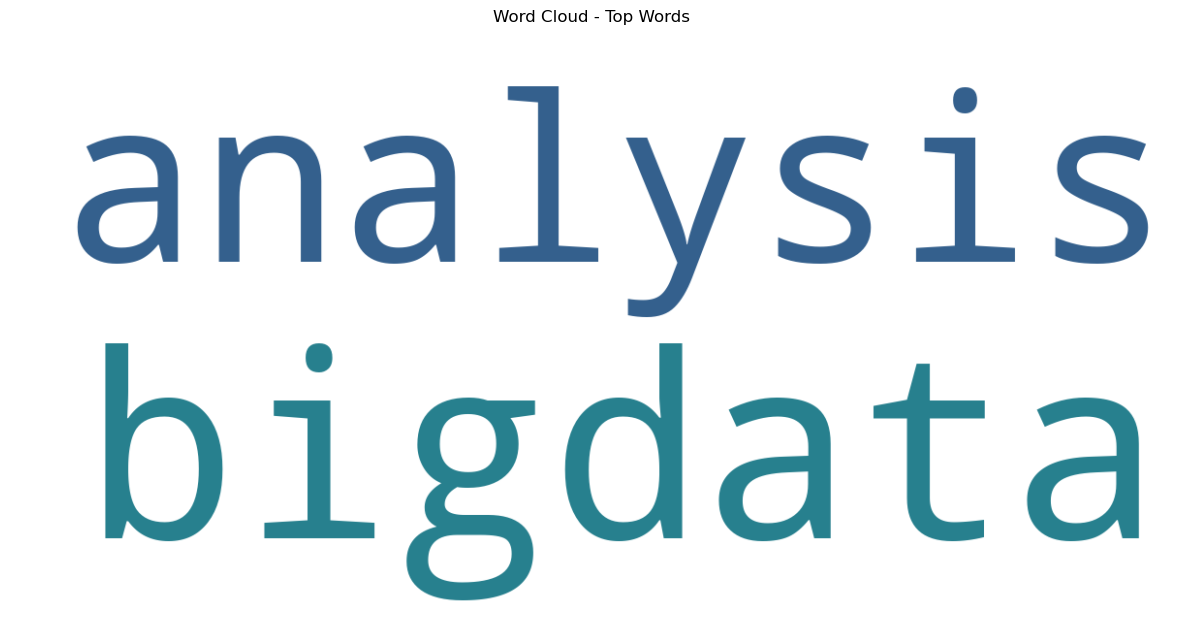

In [ ]:
# Step 4: Word Cloud Visualization

wc = WordCloud(width=1200, height=600, background_color='white', max_words=200).generate_from_frequencies(filtered_counts)

plt.figure(figsize=(15,8))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud - Top Words")
plt.show()

In [ ]:
# Step 7: Save Word Count Result

output_path = "output/word_count.csv"
os.makedirs("output", exist_ok=True)
df_word_count.to_csv(output_path, index=False)
print(f"\nWord count results saved to {output_path}")


Word count results saved to output/word_count.csv
